In [2]:
#%%
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from scipy.stats import zmap
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import glob
import os


def plot(files, nraws, title):
    num_plots = len(files)
    rows_needed = num_plots // nraws if num_plots % nraws == 0 else num_plots // nraws + 1
    # rows_needed = 1
    # fig, ax = plt.subplots(rows_needed, 1, figsize=(32,32))
    fig, ax = plt.subplots(rows_needed, nraws, figsize=(32, 32))

    if num_plots == 1:
        ax = np.array([ax])

    for csv_path in files:
        pair_name = os.path.basename(csv_path).split(".")[0]

        predict_testset_df = pd.read_csv(csv_path)
        # remove identical rows
        
        predict_testset_df = predict_testset_df[predict_testset_df["QM_Energy"] <= 50]
        predict_testset_df = predict_testset_df[predict_testset_df["FF_Energy"] <= 50]
        if len(predict_testset_df) == 0:
            print(f"Warning: {pair_name} has no data after filtering.")
            continue        
        qm_energy = predict_testset_df["QM_Energy"]
        ff_energy = predict_testset_df["FF_Energy"]

        correlation = np.corrcoef(qm_energy, ff_energy)[0, 1]
        rsquared = correlation ** 2
        mae = mean_absolute_error(qm_energy, ff_energy)
        row, col = divmod(files.index(csv_path), nraws)
        ax[row, col].scatter(qm_energy, ff_energy, s=10)
        ax[row, col].plot(qm_energy, qm_energy, color='red', linestyle='--', linewidth=1)  # y=x line
        ax[row, col].tick_params(axis='x', labelsize=24)
        ax[row, col].tick_params(axis='y', labelsize=24)
        # write pair name, data num at the up-left corner
        ax[row, col].text(0.05, 0.95, pair_name, transform=ax[row, col].transAxes,
                          fontsize=24, verticalalignment='top')
        ax[row, col].text(0.05, 0.85, f"Num: {len(predict_testset_df)}", transform=ax[row, col].transAxes,
                          fontsize=24, verticalalignment='top')
        # write r-squared value mae at the down-right corner
        ax[row, col].text(0.95, 0.05, f"MAE: {mae:.2f}", transform=ax[row, col].transAxes,
                            fontsize=24, verticalalignment='bottom', horizontalalignment='right')
        ax[row, col].text(0.95, 0.15, f"R²: {rsquared:.2f}", transform=ax[row, col].transAxes,
                          fontsize=24, verticalalignment='bottom', horizontalalignment='right')
        # set a whole title for the figure
        fig.text(0.5, 0.9, title, ha='center', fontsize=40)
        # set a whole x axis arrow
        fig.text(0.5, 0.08, 'QM Energy', ha='center', fontsize=30)
        # set a whole y axis arrow
        fig.text(0.08, 0.5, 'FF Energy', va='center', rotation='vertical', fontsize=30)

    plt.show()

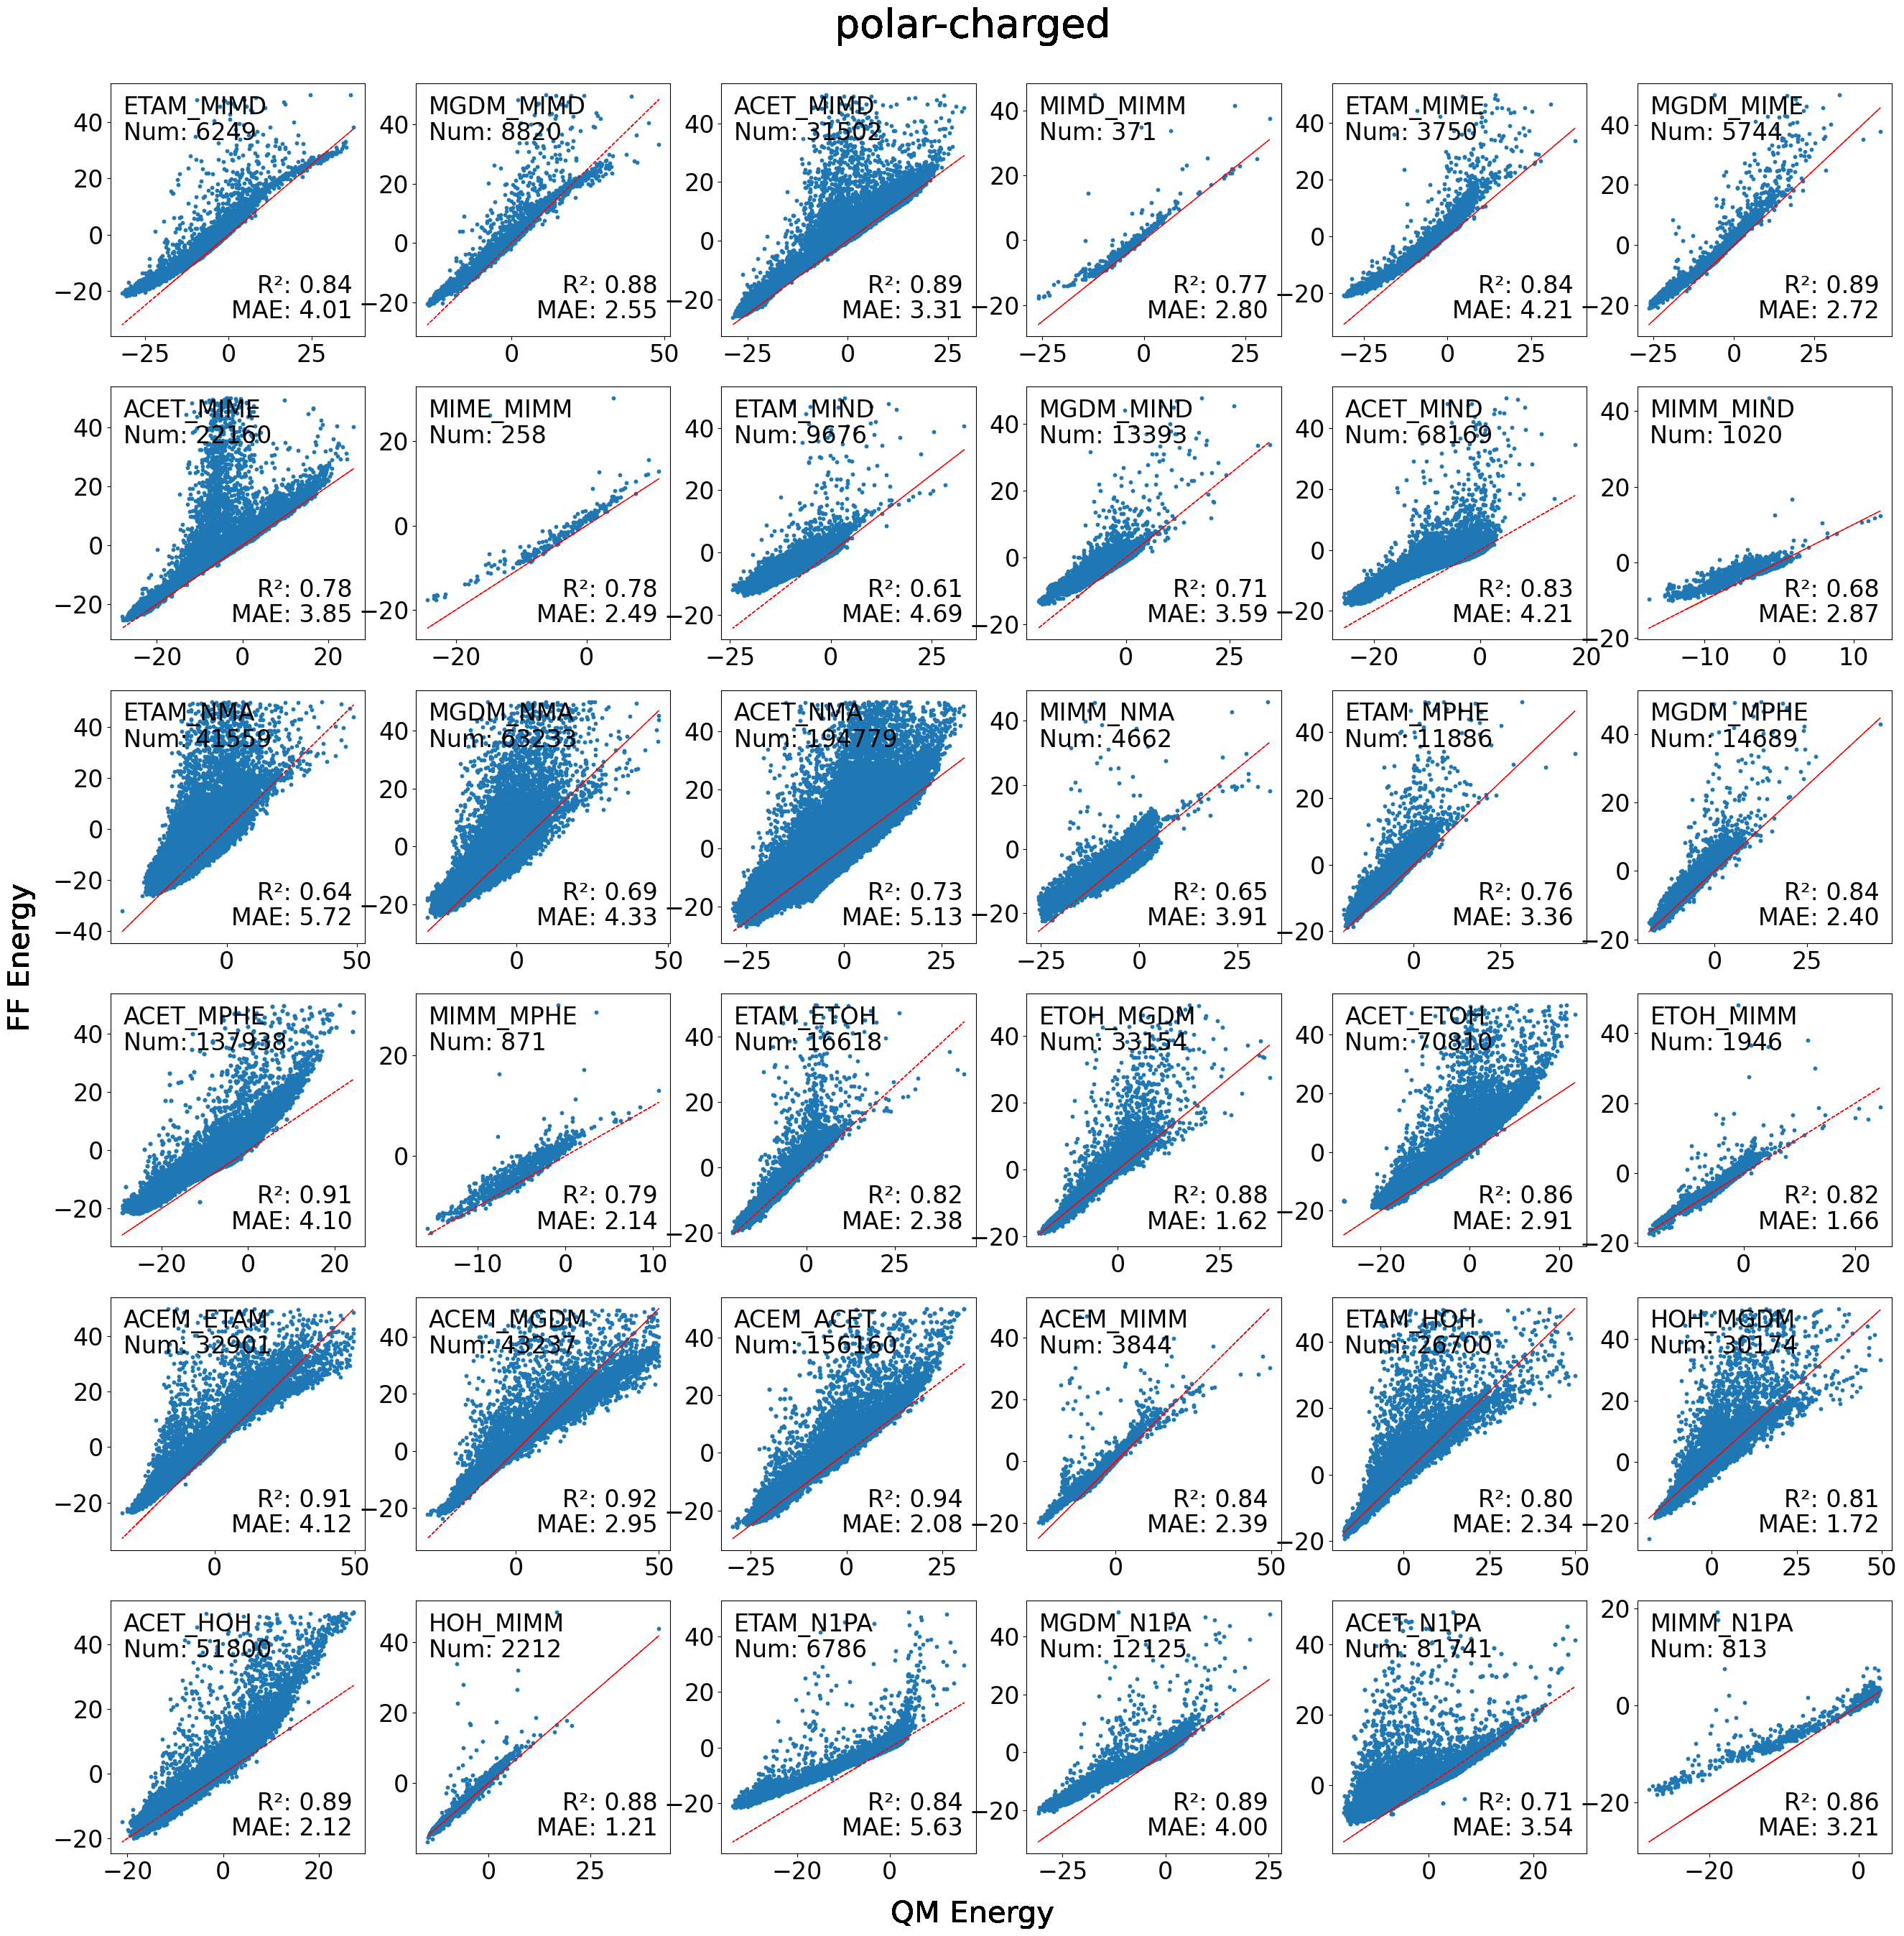

In [2]:
FragSmartsSmiles = {
    "ACEM": ("CC(N)=O", "CC(N)=O", 0),
    "ACET": ("CC([O])=O", "CC([O-])=O",-1),
    "MBZ": ("Cc1ccccc1", "Cc1ccccc1",0),
    "MIMD": ("[#6](-[#6]1-[#7](-[#6](-[#7]-[#6]-1-[H])-[H])-[H])(-[H])(-[H])-[H]", "[H]c1nc([H])n([H])c1C([H])([H])[H]",0),
    "MIME": ("[#6](-[#6]1-[#7]-[#6](-[#7](-[#6]-1-[H])-[H])-[H])(-[H])(-[H])-[H]", "[H]c1nc(c([H])([H])[H])c([H])n1[H]",0),
    "MIMM": ("[#6](-[#6]1-[#7](-[#6](-[#7](-[#6]-1-[H])-[H])-[H])-[H])(-[H])(-[H])-[H]", "n1c(C)c[nH+]c1",1),
    "MIND": ("Cc1cnc2ccccc12", "Cc1c[nH]c2ccccc12",0),
    "ETAM": ("CC[NH3+]", "CC[NH3+]",1),
    "ETOH": ("CCO", "CCO",0),
    "ETSH": ("CC[SH]", "CC[SH]",0),
    "MGDM": ("CNC(N)=[NH2]", "CNC(N)=[NH2+]",1),
    "MSM": ("CSC", "CSC",0),
    "NMA": ("CNC(~O)C", "CNC(=O)C",0),
    "MPHE": ("Cc1ccc(O)cc1", "Cc1ccc(O)cc1",0),
    "PRPA": ("C[CH1,CH2]C", "CCC",0),
    "N1PA": ("CC(~O)N1CCCC1", "CC(=O)N1CCCC1",0),
    "HOH": ("[#8](-[H])-[H]", "[H]O[H]",0)
}
hydrophobic = ["MBZ", "PRPA", "MSM", "ETSH"]
charged = ["ETAM", "MGDM", "ACET", "MIMM"]
polar = ["MIMD", "MIME", "MIND", "NMA", "MPHE", "ETOH", "ACEM", "HOH", "N1PA"]
all = hydrophobic + charged + polar
name_dict = {
    "hydrophobic" : hydrophobic,
    "polar" : polar,
    "charged" : charged,
    "all" : all
}
name1 = "polar"
name2 = "charged"
import os
os.chdir("/pubhome/xtzhang/interaction/FF/opls/data")
files = []
for fga_name in name_dict[name1]:
    for fgb_name in name_dict[name2]:
        # if not os.path.exists(os.path.join(folder, f"{fga_name}_{fgb_name}.csv")):
        #     continue
        # with open (os.path.join(folder, f"{fga_name}_{fgb_name}.csv"), "r") as f:
        #     lines = f.readlines()
        # lines[0] = "Index,FF_Energy,QM_Energy\n"
        # with open (os.path.join(folder, f"{fga_name}_{fgb_name}.csv"), "w") as f:
        #     f.writelines(lines)
        # filename = f"{fga_name}_{fgb_name}.csv"
        if f"{fga_name}_{fgb_name}.csv" in files or f"{fgb_name}_{fga_name}.csv" in files:
            continue
        if os.path.exists( f"{fga_name}_{fgb_name}.csv"):

            files.append( f"{fga_name}_{fgb_name}.csv")
        elif os.path.exists( f"{fgb_name}_{fga_name}.csv"):
            files.append( f"{fgb_name}_{fga_name}.csv")
        else:
            print(f"Warning: {fga_name}_{fgb_name}.csv not found.")
plot(files, 6, f"{name1}-{name2}")


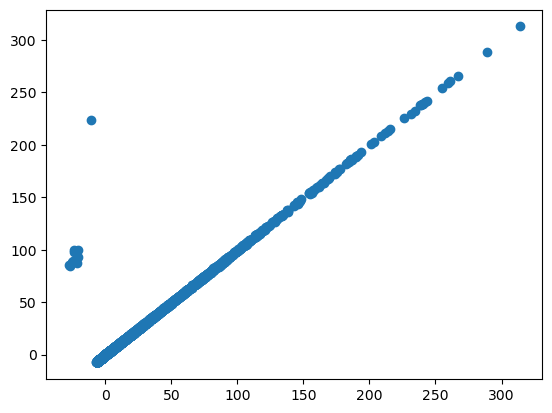

In [3]:
# 写脚本plot/pubhome/xtzhang/interaction/FF/amoeba/data/ACET_PRPA.csv中Tinker_Supermolecular_EnergyvsTinker_Intermolecular_Energy
ACET_PRPA = pd.read_csv("/pubhome/xtzhang/interaction/FF/amoeba/data/ACET_PRPA.csv")
plt.scatter(ACET_PRPA["Tinker_Supermolecular_Energy"], ACET_PRPA["Tinker_Intermolecular_Energy"])
plt.show()